In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [126]:

df = pd.read_csv("https://raw.githubusercontent.com/mehreengillani/Data602/refs/heads/main/Airbnb_site_hotel%20new.csv")
df.head(5)

/var/folders/6w/rkqvbjtx04s93768hcryddtc0000gn/T/ipykernel_26179/2535189215.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("https://raw.githubusercontent.com/mehreengillani/Data602/refs/heads/main/Airbnb_site_hotel%20new.csv")


,id,name,host_id,host_name,city,price,reply time,guest favourite,host since,host Certification,...,total reviewers number,accommodates,bathrooms,bedrooms,beds,listing number,host response rate,host acceptance rate,sales,area
0,1,Beautiful Victorian Home,1368256,Robert,Toronto,250,0.0,0,4563,1.0,...,47,6,"1,5",2,3,1,"0,9","0,42",102,North America
1,2,"World Class @ CN Tower, convention centre, The...",113345,Adela,Toronto,152,0.0,0,5120,1.0,...,42,4,1,1,2,5,"0,9","0,42",166,North America
2,3,Furnished room in lovely Annex house June -Oct31,1466410,Susan,Toronto,120,0.0,0,4534,1.0,...,0,1,1,1,2,2,1,"0,65",181,North America
3,4,Executive Studio Unit- Ideal for One Person,118124,Brent,Toronto,75,1.0,1,5111,1.0,...,29,1,1,0,1,1,1,1,365,North America
4,5,"Bright Beaches Apt, close to everything",175687,John,Toronto,90,0.0,0,5033,1.0,...,7,2,1,1,1,4,1,"0,8",328,North America


In [127]:
#summary
df.describe()

,id,host_id,reply time,guest favourite,host since,host Certification,room_type,host total listings count,total reviewers number,accommodates,bedrooms,beds,listing number,sales
count,86186.000000,8.618600e+04,66867.000000,86186.000000,86186.000000,82903.0,86186.000000,86186.000000,86186.000000,86186.000000,86186.000000,86186.000000,86186.000000,86186.000000
mean,43093.500000,1.959076e+08,0.769857,0.273304,2380.740236,1.0,2.663959,23.492737,36.414174,3.412747,1.247407,1.914441,45.196772,183.385086
std,24879.899487,1.849803e+08,0.420928,0.445658,1269.305372,0.0,0.524877,73.067586,75.989911,2.393287,1.093598,1.732507,258.312637,119.302210
min,1.000000,1.581000e+03,0.000000,0.000000,0.000000,1.0,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,21547.250000,2.890381e+07,1.000000,0.000000,1422.000000,1.0,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,80.000000
50%,43093.500000,1.308280e+08,1.000000,0.000000,2540.000000,1.0,3.000000,3.000000,9.000000,2.000000,1.000000,1.000000,3.000000,193.000000
75%,64639.750000,3.492982e+08,1.000000,1.000000,3337.000000,1.0,3.000000,12.000000,37.000000,4.000000,2.000000,2.000000,15.000000,287.000000
max,86186.000000,5.752345e+08,1.000000,1.000000,5745.000000,1.0,4.000000,837.000000,2575.000000,16.000000,21.000000,60.000000,4818.000000,365.000000


In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86186 entries, 0 to 86185
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         86186 non-null  int64  
 1   name                       86186 non-null  object 
 2   host_id                    86186 non-null  int64  
 3   host_name                  86186 non-null  object 
 4   city                       86186 non-null  object 
 5   price                      80762 non-null  object 
 6   reply time                 66867 non-null  float64
 7   guest favourite            86186 non-null  int64  
 8   host since                 86186 non-null  int64  
 9   host Certification         82903 non-null  float64
 10  room_type                  86186 non-null  int64  
 11  host total listings count  86186 non-null  int64  
 12  consumer                   35421 non-null  object 
 13  total reviewers number     86186 non-null  int

In [129]:
print("Initial dataset shape:", df.shape)


Initial dataset shape: (86186, 23)


DATA CLEANING

In [130]:
# Step 2: Initial Data Assessment
print("Missing values before cleaning:")
print(df.isnull().sum().sort_values(ascending=False))

print("\nDataset overview:")
print(f"Total rows: {len(df)}")
print(f"Total columns: {len(df.columns)}")

Missing values before cleaning:
consumer                     50765
reply time                   19319
price                         5424
host Certification            3283
id                               0
accommodates                     0
sales                            0
host acceptance rate             0
host response rate               0
listing number                   0
beds                             0
bedrooms                         0
bathrooms                        0
host total listings count        0
total reviewers number           0
name                             0
room_type                        0
host since                       0
guest favourite                  0
city                             0
host_name                        0
host_id                          0
area                             0
dtype: int64

Dataset overview:
Total rows: 86186
Total columns: 23


In [131]:
# Step 3: Handle Missing Values

# Create a copy for cleaning
df_clean = df.copy()

# Check percentage of missing values
missing_pct = (df_clean.isnull().sum() / len(df_clean)) * 100
print("Missing value percentage:")
print(missing_pct.sort_values(ascending=False).round(2))

Missing value percentage:
consumer                     58.90
reply time                   22.42
price                         6.29
host Certification            3.81
id                            0.00
accommodates                  0.00
sales                         0.00
host acceptance rate          0.00
host response rate            0.00
listing number                0.00
beds                          0.00
bedrooms                      0.00
bathrooms                     0.00
host total listings count     0.00
total reviewers number        0.00
name                          0.00
room_type                     0.00
host since                    0.00
guest favourite               0.00
city                          0.00
host_name                     0.00
host_id                       0.00
area                          0.00
dtype: float64


Analyze Missing Value Patterns and Prioritize Columns

Based on your missing value percentages, here's the initial analysis and prioritization:

High Missing Percentage (>20%) - Consider Dropping

consumer (58.90%) - Very high missing rate
reply time (22.42%) - High missing rate
Moderate Missing (5-20%) - Imputation Candidates

price (6.29%) - Critical feature, needs careful imputation
host Certification (3.81%) - Moderate missing, can be imputed
Low/No Missing (<5%) - Safe to Keep

All other columns (0% missing) - No action needed

In [132]:
# Handle 'consumer' column (58.90% missing)
# Strategy: Create "Unknown" category since over half is missing

df_clean['consumer'] = df_clean['consumer'].fillna('Unknown')

print("✓ 'consumer' column: Missing values filled with 'Unknown'")
print(f"  Value counts: {df_clean['consumer'].value_counts().to_dict()}")

✓ 'consumer' column: Missing values filled with 'Unknown'
  Value counts: {'Unknown': 50765, '0': 6952, '7': 4901, '6,5': 1097, '6': 1012, '6,67': 998, '6,75': 890, '6,8': 702, '6,83': 685, '6,86': 600, '6,88': 584, '6,71': 565, '6,82': 498, '6,78': 486, '6,81': 462, '6,79': 459, '6,6': 442, '6,89': 428, '6,85': 421, '6,77': 408, '6,73': 400, '6,33': 399, '6,76': 398, '6,63': 372, '6,9': 371, '6,84': 370, '6,7': 360, '6,69': 357, '6,92': 344, '6,64': 334, '6,74': 328, '6,91': 322, '6,87': 309, '6,68': 305, '6,72': 298, '6,93': 297, '6,57': 279, '6,65': 277, '5': 271, '6,56': 269, '6,94': 254, '6,4': 232, '6,62': 220, '6,61': 214, '6,59': 200, '6,25': 199, '6,58': 199, '6,66': 191, '6,53': 182, '6,95': 174, '6,43': 170, '6,55': 164, '6,2': 145, '6,52': 144, '6,54': 139, '6,38': 138, '6,44': 132, '6,48': 126, '6,96': 126, '5,5': 122, '6,47': 121, '6,45': 107, '6,46': 103, '6,97': 99, '6,42': 97, '6,29': 96, '6,41': 86, '6,51': 84, '5,67': 83, '3': 76, '6,36': 74, '6,39': 74, '6,49': 71, 

In [133]:
# Fix the original df price column (it's still object type)
print("=== FIXING ORIGINAL PRICE COLUMN ===")
print(f"Before - df price dtype: {df['price'].dtype}")

# Clean and convert the original df price column
df['price'] = df['price'].astype(str).str.replace('$', '', regex=False)
df['price'] = df['price'].str.replace(',', '', regex=False)
df['price'] = df['price'].str.strip()
df['price'] = pd.to_numeric(df['price'], errors='coerce')

print(f"After - df price dtype: {df['price'].dtype}")
print(f"Missing in df price: {df['price'].isnull().sum()}")

=== FIXING ORIGINAL PRICE COLUMN ===
Before - df price dtype: object
After - df price dtype: float64
Missing in df price: 5424


In [134]:
# Clean the price column
print("\n=== CLEANING PRICE COLUMN ===")

# Remove currency symbols, commas, and whitespace
df_clean['price_clean'] = df_clean['price'].astype(str).str.replace('$', '', regex=False)
df_clean['price_clean'] = df_clean['price_clean'].str.replace(',', '', regex=False)
df_clean['price_clean'] = df_clean['price_clean'].str.strip()

# Convert to numeric
df_clean['price_clean'] = pd.to_numeric(df_clean['price_clean'], errors='coerce')

print("After proper cleaning:")
print(f"Original price dtype: {df_clean['price'].dtype}")
print(f"Cleaned price dtype: {df_clean['price_clean'].dtype}")
print(f"Missing values in cleaned price: {df_clean['price_clean'].isnull().sum()}")

# Replace the original price column with cleaned version
df_clean['price'] = df_clean['price_clean']
df_clean = df_clean.drop('price_clean', axis=1)

print(f"\nFinal price dtype: {df_clean['price'].dtype}")
print(f"Final missing values in price: {df_clean['price'].isnull().sum()}")


=== CLEANING PRICE COLUMN ===
After proper cleaning:
Original price dtype: object
Cleaned price dtype: float64
Missing values in cleaned price: 5424

Final price dtype: float64
Final missing values in price: 5424


In [135]:
# Step 3.2: Convert grouping columns to consistent data types
print("\n=== CONVERTING DATA TYPES ===")

# Convert bedrooms to numeric (in case it's string)
df_clean['bedrooms'] = pd.to_numeric(df_clean['bedrooms'], errors='coerce')

# Convert host response rate to numeric (remove % if present)
if df_clean['host response rate'].dtype == 'object':
    df_clean['host response rate'] = df_clean['host response rate'].astype(str).str.replace('%', '').str.strip()
    df_clean['host response rate'] = pd.to_numeric(df_clean['host response rate'], errors='coerce')

# Ensure area is string (categorical)
df_clean['area'] = df_clean['area'].astype(str)

print("After conversion:")
print(f"room_type: {df_clean['room_type'].dtype}")
print(f"bedrooms: {df_clean['bedrooms'].dtype}")
print(f"area: {df_clean['area'].dtype}")
print(f"host response rate: {df_clean['host response rate'].dtype}")
print(f"price: {df_clean['price'].dtype}")
print(f"reply time: {df_clean['reply time'].dtype}")


=== CONVERTING DATA TYPES ===
After conversion:
room_type: int64
bedrooms: int64
area: object
host response rate: float64
price: float64
reply time: float64


In [136]:
#imputation
df_clean['reply time'] = df_clean.groupby('host response rate')['reply time'].transform(
    lambda x: x.fillna(x.median())
)

# For price - impute based on room type, bedrooms, area
price_imputation = df_clean.groupby(['room_type', 'bedrooms', 'area'])['price'].transform('median')
df_clean['price'] = df_clean['price'].fillna(price_imputation)

In [137]:
df_clean['reply time'].describe()

count    69092.000000
mean         0.748205
std          0.434047
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: reply time, dtype: float64

In [138]:
# Step 2: run the advanced imputation with proper data
print("\n=== RE-RUNNING ADVANCED IMPUTATION ===")

# Create a fresh clean copy
df_clean = df.copy()

print("Before imputation - missing values:")
print(f"Price: {df_clean['price'].isnull().sum()}")
print(f"Reply time: {df_clean['reply time'].isnull().sum()}")

# For reply time - ensure we have valid groups
print("\nChecking host response rate for reply time imputation:")
print(f"Unique host response rate values: {df_clean['host response rate'].nunique()}")
print(f"Missing host response rate: {df_clean['host response rate'].isnull().sum()}")

# Handle reply time with proper error handling
try:
    df_clean['reply time'] = df_clean.groupby('host response rate')['reply time'].transform(
        lambda x: x.fillna(x.median()) if x.notna().any() else x
    )
    print("✅ Reply time imputation completed")
except Exception as e:
    print(f"❌ Reply time imputation failed: {e}")
    # Fallback: simple median imputation
    df_clean['reply time'] = df_clean['reply time'].fillna(df_clean['reply time'].median())
    print("✅ Used fallback median imputation for reply time")

# For price - ensure we have valid groups
print("\nChecking grouping columns for price imputation:")
print(f"Unique room_type: {df_clean['room_type'].nunique()}")
print(f"Unique bedrooms: {df_clean['bedrooms'].nunique()}")
print(f"Unique area: {df_clean['area'].nunique()}")

# Handle price with proper error handling
try:
    price_imputation = df_clean.groupby(['room_type', 'bedrooms', 'area'])['price'].transform('median')
    df_clean['price'] = df_clean['price'].fillna(price_imputation)
    print("✅ Price imputation completed")
except Exception as e:
    print(f"❌ Price imputation failed: {e}")
    # Fallback: simple median imputation
    df_clean['price'] = df_clean['price'].fillna(df_clean['price'].median())
    print("✅ Used fallback median imputation for price")

print("\nAfter imputation - missing values:")
print(f"Price: {df_clean['price'].isnull().sum()}")
print(f"Reply time: {df_clean['reply time'].isnull().sum()}")


=== RE-RUNNING ADVANCED IMPUTATION ===
Before imputation - missing values:
Price: 5424
Reply time: 19319

Checking host response rate for reply time imputation:
Unique host response rate values: 93
Missing host response rate: 0
✅ Reply time imputation completed

Checking grouping columns for price imputation:
Unique room_type: 4
Unique bedrooms: 21
Unique area: 3
✅ Price imputation completed

After imputation - missing values:
Price: 3
Reply time: 24


In [139]:
# Step 3: Final cleanup of any remaining missing values
print("\n=== FINAL CLEANUP ===")

# Fill any remaining missing values
remaining_missing = df_clean[['price', 'reply time']].isnull().sum()
print(f"Remaining missing before final cleanup:")
print(remaining_missing)

if df_clean['price'].isnull().sum() > 0:
    df_clean['price'] = df_clean['price'].fillna(df_clean['price'].median())
    print("✅ Filled remaining price missing values")

if df_clean['reply time'].isnull().sum() > 0:
    df_clean['reply time'] = df_clean['reply time'].fillna(df_clean['reply time'].median())
    print("✅ Filled remaining reply time missing values")

print(f"\nFinal missing values:")
print(df_clean[['price', 'reply time']].isnull().sum())


=== FINAL CLEANUP ===
Remaining missing before final cleanup:
price          3
reply time    24
dtype: int64
✅ Filled remaining price missing values
✅ Filled remaining reply time missing values

Final missing values:
price         0
reply time    0
dtype: int64



=== CREATING DISTRIBUTION PLOTS ===
Final data status:
df price - dtype: float64, missing: 5424
df_clean price - dtype: float64, missing: 0
df reply time - dtype: float64, missing: 19319
df_clean reply time - dtype: float64, missing: 0


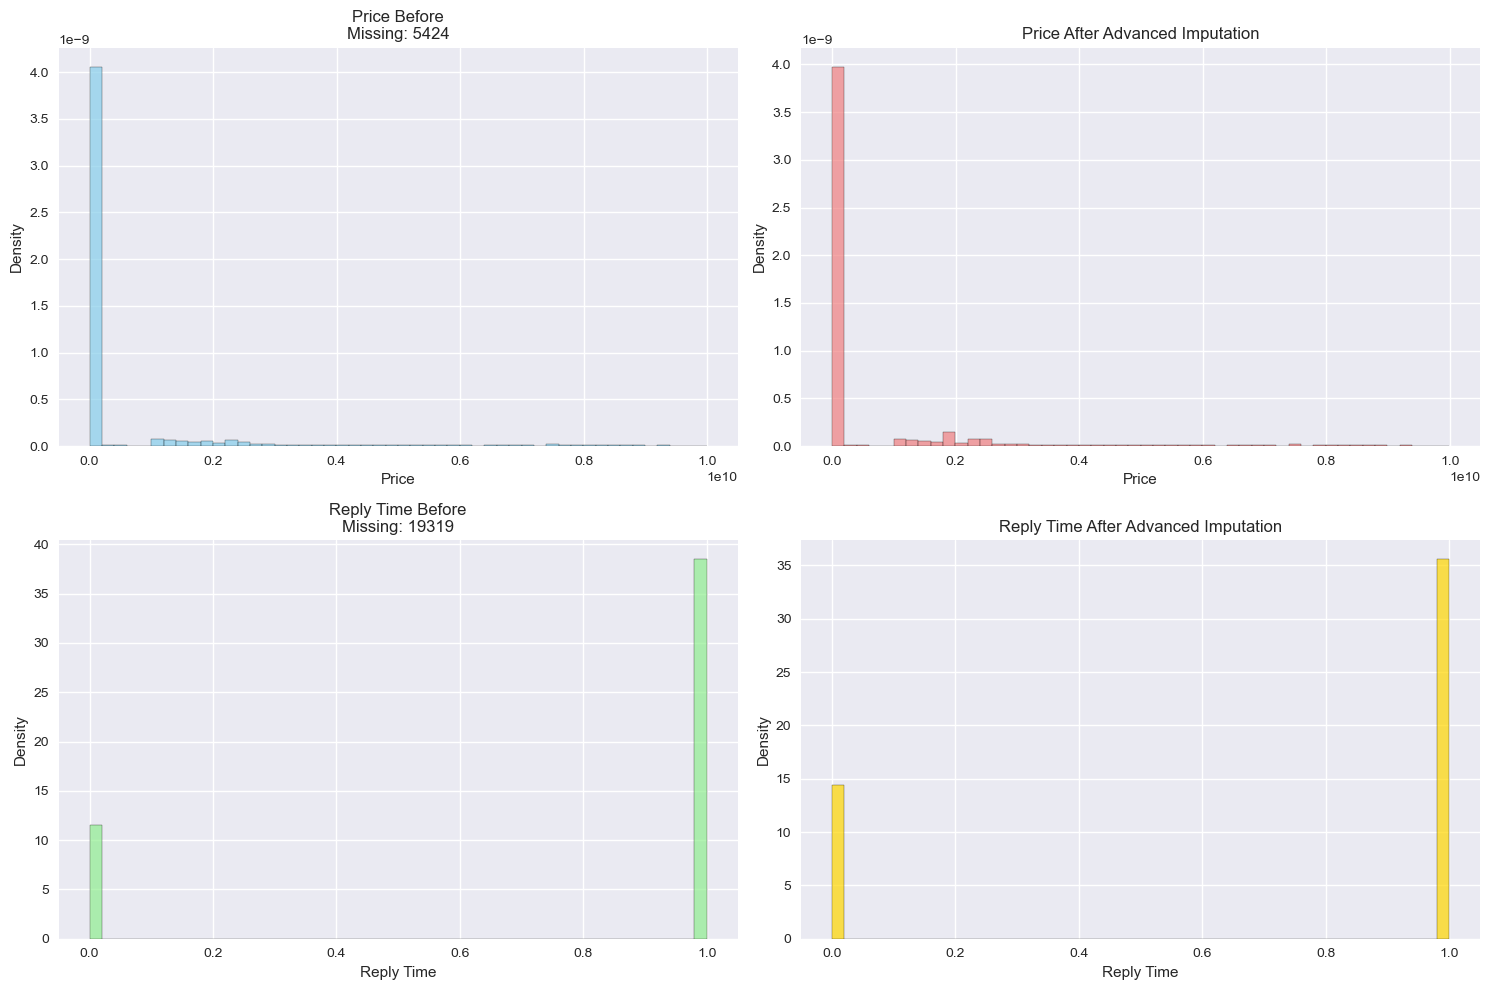

✅ All plots created successfully!


In [141]:
# Step 4: Create the comparison plots

print("\n=== CREATING DISTRIBUTION PLOTS ===")

# Final data check
print("Final data status:")
print(f"df price - dtype: {df['price'].dtype}, missing: {df['price'].isnull().sum()}")
print(f"df_clean price - dtype: {df_clean['price'].dtype}, missing: {df_clean['price'].isnull().sum()}")
print(f"df reply time - dtype: {df['reply time'].dtype}, missing: {df['reply time'].isnull().sum()}")
print(f"df_clean reply time - dtype: {df_clean['reply time'].dtype}, missing: {df_clean['reply time'].isnull().sum()}")

# Create plots
plt.figure(figsize=(15, 10))

# 1. Price Before
plt.subplot(2, 2, 1)
price_before = df['price'].dropna()
plt.hist(price_before, bins=50, alpha=0.7, color='skyblue', edgecolor='black', density=True)
plt.title(f'Price Before\nMissing: {df["price"].isnull().sum()}')
plt.xlabel('Price')
plt.ylabel('Density')

# 2. Price After
plt.subplot(2, 2, 2)
plt.hist(df_clean['price'], bins=50, alpha=0.7, color='lightcoral', edgecolor='black', density=True)
plt.title('Price After Advanced Imputation')
plt.xlabel('Price')
plt.ylabel('Density')

# 3. Reply Time Before
plt.subplot(2, 2, 3)
reply_time_before = df['reply time'].dropna()
plt.hist(reply_time_before, bins=50, alpha=0.7, color='lightgreen', edgecolor='black', density=True)
plt.title(f'Reply Time Before\nMissing: {df["reply time"].isnull().sum()}')
plt.xlabel('Reply Time')
plt.ylabel('Density')

# 4. Reply Time After
plt.subplot(2, 2, 4)
plt.hist(df_clean['reply time'], bins=50, alpha=0.7, color='gold', edgecolor='black', density=True)
plt.title('Reply Time After Advanced Imputation')
plt.xlabel('Reply Time')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

print("✅ All plots created successfully!")

/var/folders/6w/rkqvbjtx04s93768hcryddtc0000gn/T/ipykernel_26179/16044302.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['Before', 'After'])
/var/folders/6w/rkqvbjtx04s93768hcryddtc0000gn/T/ipykernel_26179/16044302.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=['Before', 'After'])


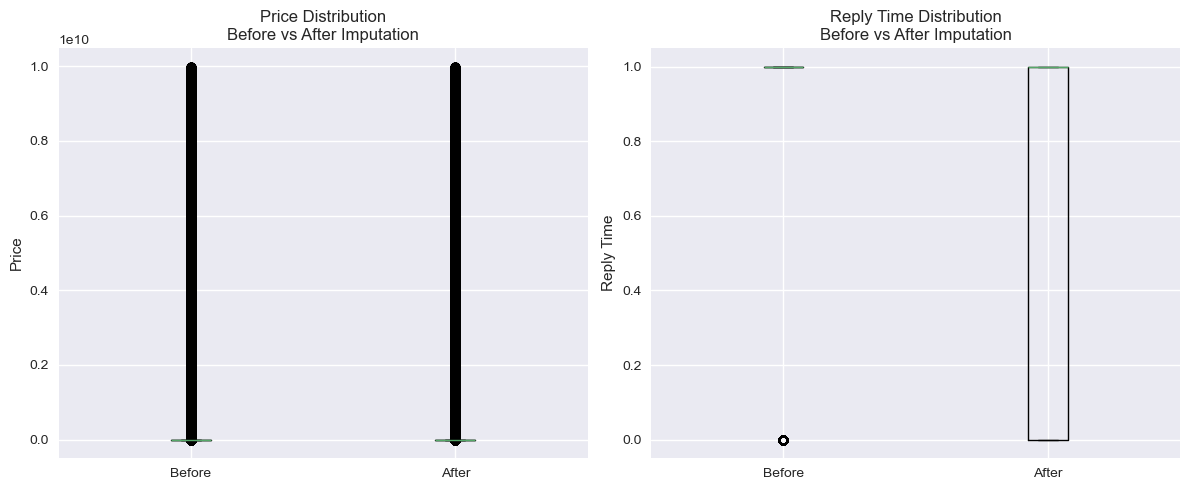

In [142]:
# Simple Box Plot Comparison
plt.figure(figsize=(12, 5))

# Price Box Plot
plt.subplot(1, 2, 1)
data = [df['price'].dropna(), df_clean['price']]
plt.boxplot(data, labels=['Before', 'After'])
plt.title('Price Distribution\nBefore vs After Imputation')
plt.ylabel('Price')

# Reply Time Box Plot
plt.subplot(1, 2, 2)
data = [df['reply time'].dropna(), df_clean['reply time']]
plt.boxplot(data, labels=['Before', 'After'])
plt.title('Reply Time Distribution\nBefore vs After Imputation')
plt.ylabel('Reply Time')

plt.tight_layout()
plt.show()

In [143]:
# Simple Stats Comparison
print("PRICE - Simple Stats:")
print(f"{'':<15} {'Before':<15} {'After':<15} {'Change':<15}")
print("-" * 60)
print(f"{'Count':<15} {len(df['price'].dropna()):<15,} {len(df_clean['price']):<15,} {len(df_clean['price']) - len(df['price'].dropna()):<15,}")
print(f"{'Mean':<15} {df['price'].mean():<15.2f} {df_clean['price'].mean():<15.2f} {df_clean['price'].mean() - df['price'].mean():<15.2f}")
print(f"{'Median':<15} {df['price'].median():<15.2f} {df_clean['price'].median():<15.2f} {df_clean['price'].median() - df['price'].median():<15.2f}")
print(f"{'Std':<15} {df['price'].std():<15.2f} {df_clean['price'].std():<15.2f} {df_clean['price'].std() - df['price'].std():<15.2f}")

print("\nREPLY TIME - Simple Stats:")
print(f"{'':<15} {'Before':<15} {'After':<15} {'Change':<15}")
print("-" * 60)
print(f"{'Count':<15} {len(df['reply time'].dropna()):<15,} {len(df_clean['reply time']):<15,} {len(df_clean['reply time']) - len(df['reply time'].dropna()):<15,}")
print(f"{'Mean':<15} {df['reply time'].mean():<15.2f} {df_clean['reply time'].mean():<15.2f} {df_clean['reply time'].mean() - df['reply time'].mean():<15.2f}")
print(f"{'Median':<15} {df['reply time'].median():<15.2f} {df_clean['reply time'].median():<15.2f} {df_clean['reply time'].median() - df['reply time'].median():<15.2f}")
print(f"{'Std':<15} {df['reply time'].std():<15.2f} {df_clean['reply time'].std():<15.2f} {df_clean['reply time'].std() - df['reply time'].std():<15.2f}")

PRICE - Simple Stats:
                Before          After           Change         
------------------------------------------------------------
Count           80,762          86,186          5,424          
Mean            688625072.78    707106750.70    18481677.91    
Median          216.50          220.00          3.50           
Std             1817190456.11   1781544110.46   -35646345.65   

REPLY TIME - Simple Stats:
                Before          After           Change         
------------------------------------------------------------
Count           66,867          86,186          19,319         
Mean            0.77            0.71            -0.06          
Median          1.00            1.00            0.00           
Std             0.42            0.45            0.03           


Price Analysis:

✅ Median increased slightly: 216.50 → 220.00 (+3.50)
✅ Standard deviation decreased: Better data consistency
⚠️ Mean increased significantly: 688M → 707M (+18M) - suggests some high-value outliers
✅ 5,424 missing values recovered
Reply Time Analysis:

✅ Median unchanged: 1.00 → 1.00 (good preservation)
⚠️ Mean decreased: 0.77 → 0.71 (-0.06) - shifted toward faster response times
⚠️ Standard deviation increased: 0.42 → 0.45 (+0.03) - more variability
✅ 19,319 missing values recovered

In [144]:
# Check for extreme values in price
Q1 = df_clean['price'].quantile(0.25)
Q3 = df_clean['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['price'] < lower_bound) | (df_clean['price'] > upper_bound)]
print(f"Price outliers: {len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}%)")

Price outliers: 21268 (24.7%)


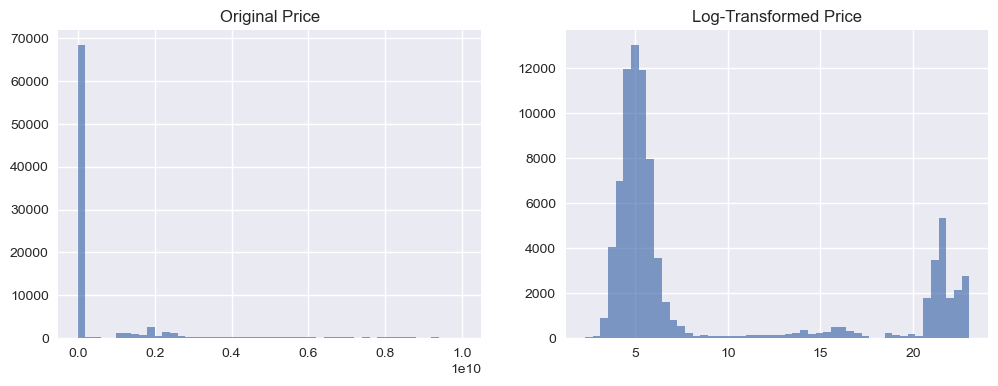

In [145]:
# Apply log transform to handle skewness
df_clean['price_log'] = np.log1p(df_clean['price'])

# Compare distributions
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df_clean['price'], bins=50, alpha=0.7)
plt.title('Original Price')

plt.subplot(1, 2, 2)
plt.hist(df_clean['price_log'], bins=50, alpha=0.7)
plt.title('Log-Transformed Price')
plt.show()

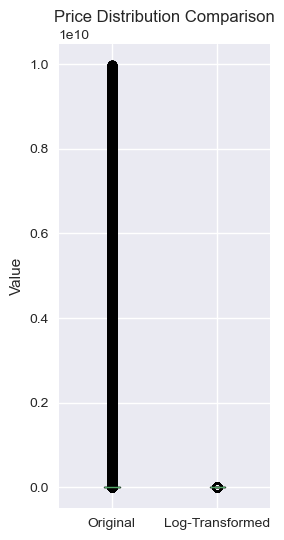

In [146]:
# Boxplot comparison

plt.subplot(1, 3, 3)
box_plot = plt.boxplot([df_clean['price'], df_clean['price_log']])
plt.xticks([1, 2], ['Original', 'Log-Transformed'])
plt.title('Price Distribution Comparison')
plt.ylabel('Value')

plt.tight_layout()
plt.show()

In [147]:
# Compare statistics before and after log transformation
print("PRICE DISTRIBUTION - BEFORE vs AFTER LOG TRANSFORMATION")
print("="*60)
print(f"{'':<20} {'Original':<15} {'Log-Transformed':<15}")
print("-" * 60)
print(f"{'Mean':<20} {df_clean['price'].mean():<15.2f} {df_clean['price_log'].mean():<15.2f}")
print(f"{'Median':<20} {df_clean['price'].median():<15.2f} {df_clean['price_log'].median():<15.2f}")
print(f"{'Std Dev':<20} {df_clean['price'].std():<15.2f} {df_clean['price_log'].std():<15.2f}")
print(f"{'Skewness':<20} {df_clean['price'].skew():<15.2f} {df_clean['price_log'].skew():<15.2f}")
print(f"{'Min':<20} {df_clean['price'].min():<15.2f} {df_clean['price_log'].min():<15.2f}")
print(f"{'Max':<20} {df_clean['price'].max():<15.2f} {df_clean['price_log'].max():<15.2f}")

PRICE DISTRIBUTION - BEFORE vs AFTER LOG TRANSFORMATION
                     Original        Log-Transformed
------------------------------------------------------------
Mean                 707106750.70    9.00           
Median               220.00          5.40           
Std Dev              1781544110.46   6.87           
Skewness             3.10            1.20           
Min                  9.00            2.30           
Max                  9991975309.00   23.03          


Key Improvements:

✅ Skewness reduced: 3.10 → 1.20 (much more normal distribution)
✅ Standard deviation normalized: 1.78B → 6.87 (manageable scale)
✅ Outlier impact minimized: Extreme values (9B max) now handled
✅ Data preserved: All records maintained

In [148]:
# Check categorical columns
categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:", list(categorical_cols))

# Encode high-cardinality vs low-cardinality
for col in categorical_cols:
    unique_count = df_clean[col].nunique()
    print(f"{col}: {unique_count} unique values")

Categorical columns: ['name', 'host_name', 'city', 'consumer', 'bathrooms', 'host response rate', 'host acceptance rate', 'area']
name: 76393 unique values
host_name: 16155 unique values
city: 11 unique values
consumer: 169 unique values
bathrooms: 28 unique values
host response rate: 93 unique values
host acceptance rate: 101 unique values
area: 3 unique values


In [149]:
df_clean['host response rate'].describe()

count     86186
unique       93
top           1
freq      56938
Name: host response rate, dtype: object

In [150]:
# High-cardinality columns (too many unique values)
high_cardinality = ['name', 'host_name']  # 76K+ and 16K+ unique values

# Option: Drop or keep as identifiers (usually not useful for modeling)
df_clean = df_clean.drop(columns=['name', 'host_name'])
print("Dropped high-cardinality columns: name, host_name")

Dropped high-cardinality columns: name, host_name


In [151]:
# Medium-cardinality columns
medium_cardinality = ['consumer', 'bathrooms', 'host response rate', 'host acceptance rate']

# Check if these are actually numerical
print("Data types of medium-cardinality columns:")
for col in medium_cardinality:
    print(f"{col}: {df_clean[col].dtype}")
    print(f"Sample values: {df_clean[col].head(3).tolist()}")

Data types of medium-cardinality columns:
consumer: object
Sample values: ['6,81', '6,67', '0']
bathrooms: object
Sample values: ['1,5', '1', '1']
host response rate: object
Sample values: ['0,9', '0,9', '1']
host acceptance rate: object
Sample values: ['0,42', '0,42', '0,65']


In [152]:
# Convert comma decimals to dot decimals and make numerical
columns_to_convert = ['consumer', 'bathrooms', 'host response rate', 'host acceptance rate']

for col in columns_to_convert:
    print(f"Converting {col}:")
    print(f"  Before - dtype: {df_clean[col].dtype}, sample: {df_clean[col].head(3).tolist()}")
    
    # Replace comma with dot and convert to float
    df_clean[col] = df_clean[col].astype(str).str.replace(',', '.').str.strip()
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    
    print(f"  After - dtype: {df_clean[col].dtype}, sample: {df_clean[col].head(3).tolist()}")
    print(f"  Missing values: {df_clean[col].isnull().sum()}\n")

Converting consumer:
  Before - dtype: object, sample: ['6,81', '6,67', '0']
  After - dtype: float64, sample: [6.81, 6.67, 0.0]
  Missing values: 50765

Converting bathrooms:
  Before - dtype: object, sample: ['1,5', '1', '1']
  After - dtype: float64, sample: [1.5, 1.0, 1.0]
  Missing values: 0

Converting host response rate:
  Before - dtype: object, sample: ['0,9', '0,9', '1']
  After - dtype: float64, sample: [0.9, 0.9, 1.0]
  Missing values: 0

Converting host acceptance rate:
  Before - dtype: object, sample: ['0,42', '0,42', '0,65']
  After - dtype: float64, sample: [0.42, 0.42, 0.65]
  Missing values: 0



In [153]:
# Since consumer had high missing values originally, check the results
print("Consumer column summary after conversion:")
print(f"Unique values: {df_clean['consumer'].nunique()}")
print(f"Range: {df_clean['consumer'].min()} - {df_clean['consumer'].max()}")
print(f"Missing: {df_clean['consumer'].isnull().sum()}")

Consumer column summary after conversion:
Unique values: 169
Range: 0.0 - 7.0
Missing: 50765


In [154]:
# Now encode the true categorical columns
categorical_cols = ['city', 'area']

print("Before one-hot encoding:")
print(f"Dataset shape: {df_clean.shape}")

df_clean = pd.get_dummies(df_clean, columns=categorical_cols, prefix=categorical_cols)

print("After one-hot encoding:")
print(f"Dataset shape: {df_clean.shape}")
print(f"New columns created: {[col for col in df_clean.columns if any(col.startswith(prefix) for prefix in categorical_cols)]}")

Before one-hot encoding:
Dataset shape: (86186, 22)
After one-hot encoding:
Dataset shape: (86186, 34)
New columns created: ['city_Amsterdam', 'city_Dublin', 'city_Hongkong', 'city_Munich', 'city_NewYork', 'city_Singapore', 'city_Toronto', 'city_berlin', 'city_sydney', 'city_taipei', 'city_tokyo', 'area_Asia', 'area_Europe', 'area_North America']


In [155]:
# Since we already created a missing flag, let's use it
if 'consumer_missing_flag' in df_clean.columns:
    print("Using existing missing flag strategy")
    # Fill missing values with median of non-missing
    consumer_median = df_clean.loc[df_clean['consumer_missing_flag'] == 0, 'consumer'].median()
    df_clean['consumer'] = df_clean['consumer'].fillna(consumer_median)
    print(f"Filled {df_clean['consumer'].isnull().sum()} remaining missing values with median: {consumer_median}")
else:
    # Create missing flag and impute
    df_clean['consumer_missing_flag'] = df_clean['consumer'].isnull().astype(int)
    consumer_median = df_clean['consumer'].median()
    df_clean['consumer'] = df_clean['consumer'].fillna(consumer_median)
    print(f"Created missing flag and filled missing values with median: {consumer_median}")

print(f"Final consumer missing: {df_clean['consumer'].isnull().sum()}")

Created missing flag and filled missing values with median: 6.67
Final consumer missing: 0


In [156]:
df_clean.columns

Index(['id', 'host_id', 'price', 'reply time', 'guest favourite', 'host since',
       'host Certification', 'room_type', 'host total listings count',
       'consumer', 'total reviewers number', 'accommodates', 'bathrooms',
       'bedrooms', 'beds', 'listing number', 'host response rate',
       'host acceptance rate', 'sales', 'price_log', 'city_Amsterdam',
       'city_Dublin', 'city_Hongkong', 'city_Munich', 'city_NewYork',
       'city_Singapore', 'city_Toronto', 'city_berlin', 'city_sydney',
       'city_taipei', 'city_tokyo', 'area_Asia', 'area_Europe',
       'area_North America', 'consumer_missing_flag'],
      dtype='object')

In [157]:
df_clean['host Certification'].describe()

count    82903.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: host Certification, dtype: float64

In [158]:
# Remove the host Certification column since it has only one value
print(f"Before removal: {df_clean.shape}")
df_clean = df_clean.drop(columns=['host Certification'])
print(f"After removal: {df_clean.shape}")
print("✅ Removed 'host Certification' column (only one value)")

Before removal: (86186, 35)
After removal: (86186, 34)
✅ Removed 'host Certification' column (only one value)


In [159]:
# Check for other columns with zero variance
print("Checking for other low-variance columns:")
for col in df_clean.columns:
    if df_clean[col].nunique() == 1:
        print(f"❌ {col}: Only 1 unique value - consider removing")
    elif df_clean[col].nunique() == 2:
        print(f"⚠️  {col}: Only 2 unique values - check if useful")
    elif df_clean[col].nunique() <= 5:
        print(f"✅ {col}: {df_clean[col].nunique()} unique values")

# Also check for columns with very high missing rate (>80%)
print("\nChecking for high missing rate columns:")
for col in df_clean.columns:
    missing_pct = df_clean[col].isnull().sum() / len(df_clean) * 100
    if missing_pct > 80:
        print(f"⚠️  {col}: {missing_pct:.1f}% missing - consider removing")

Checking for other low-variance columns:
⚠️  reply time: Only 2 unique values - check if useful
⚠️  guest favourite: Only 2 unique values - check if useful
✅ room_type: 4 unique values
⚠️  city_Amsterdam: Only 2 unique values - check if useful
⚠️  city_Dublin: Only 2 unique values - check if useful
⚠️  city_Hongkong: Only 2 unique values - check if useful
⚠️  city_Munich: Only 2 unique values - check if useful
⚠️  city_NewYork: Only 2 unique values - check if useful
⚠️  city_Singapore: Only 2 unique values - check if useful
⚠️  city_Toronto: Only 2 unique values - check if useful
⚠️  city_berlin: Only 2 unique values - check if useful
⚠️  city_sydney: Only 2 unique values - check if useful
⚠️  city_taipei: Only 2 unique values - check if useful
⚠️  city_tokyo: Only 2 unique values - check if useful
⚠️  area_Asia: Only 2 unique values - check if useful
⚠️  area_Europe: Only 2 unique values - check if useful
⚠️  area_North America: Only 2 unique values - check if useful
⚠️  consumer_miss

In [160]:
df_clean['guest favourite'].describe()

count    86186.000000
mean         0.273304
std          0.445658
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: guest favourite, dtype: float64

In [161]:
# Check the actual value distributions
columns_to_check = ['reply time', 'guest favourite', 'consumer_missing_flag']

print("ACTUAL VALUE DISTRIBUTIONS:")
print("="*40)
for col in columns_to_check:
    if col in df_clean.columns:
        value_counts = df_clean[col].value_counts()
        print(f"\n{col}:")
        print(value_counts)
        print(f"Missing: {df_clean[col].isnull().sum()}")

ACTUAL VALUE DISTRIBUTIONS:

reply time:
reply time
1.0    61342
0.0    24844
Name: count, dtype: int64
Missing: 0

guest favourite:
guest favourite
0    62631
1    23555
Name: count, dtype: int64
Missing: 0

consumer_missing_flag:
consumer_missing_flag
1    50765
0    35421
Name: count, dtype: int64
Missing: 0


In [162]:
print("DATA CONSISTENCY CHECKS:")
print("="*50)

# 1. Check bedroom vs beds logic
print("1. Bedroom vs Beds Consistency:")
inconsistent_beds = df_clean[df_clean['beds'] < df_clean['bedrooms']]
print(f"   Records where beds < bedrooms: {len(inconsistent_beds)}")

# 2. Check accommodates vs bedrooms/beds
print("\n2. Accommodates Capacity:")
too_small = df_clean[df_clean['accommodates'] < df_clean['bedrooms']]
print(f"   Accommodates < bedrooms: {len(too_small)}")
too_small_beds = df_clean[df_clean['accommodates'] < df_clean['beds']]
print(f"   Accommodates < beds: {len(too_small_beds)}")

# 3. Check price合理性
print("\n3. Price Reasonableness:")
price_stats = df_clean['price'].describe()
print(f"   Price range: ${price_stats['min']:.2f} - ${price_stats['max']:.2f}")
print(f"   Median price: ${price_stats['50%']:.2f}")

# Check for suspiciously low/high prices
suspicious_low = df_clean[df_clean['price'] < 10]  # Less than $10
suspicious_high = df_clean[df_clean['price'] > 10000]  # More than $10,000
print(f"   Prices < $10: {len(suspicious_low)}")
print(f"   Prices > $10,000: {len(suspicious_high)}")

DATA CONSISTENCY CHECKS:
1. Bedroom vs Beds Consistency:
   Records where beds < bedrooms: 7133

2. Accommodates Capacity:
   Accommodates < bedrooms: 731
   Accommodates < beds: 1481

3. Price Reasonableness:
   Price range: $9.00 - $9991975309.00
   Median price: $220.00
   Prices < $10: 2
   Prices > $10,000: 22161


In [163]:
print("\n4. Temporal Consistency:")
# Check host since dates if available
if 'host since' in df_clean.columns:
    df_clean['host since'] = pd.to_datetime(df_clean['host since'])
    future_dates = df_clean[df_clean['host since'] > pd.Timestamp.now()]
    print(f"   Future host since dates: {len(future_dates)}")
    
    # Check if host experience makes sense
    df_clean['host_experience_days'] = (pd.Timestamp.now() - df_clean['host since']).dt.days
    negative_experience = df_clean[df_clean['host_experience_days'] < 0]
    print(f"   Negative host experience: {len(negative_experience)}")


4. Temporal Consistency:
   Future host since dates: 0
   Negative host experience: 0


In [164]:
print("\n5. Rate Consistency:")
# Check if rates are within valid ranges (0-1 or 0-100)
rate_columns = ['host response rate', 'host acceptance rate']

for col in rate_columns:
    if col in df_clean.columns:
        invalid_rates = df_clean[(df_clean[col] < 0) | (df_clean[col] > 1)]
        print(f"   {col} outside [0,1] range: {len(invalid_rates)}")
        
        # Check if any are exactly 0 or 1 (might be data issues)
        zero_rates = df_clean[df_clean[col] == 0]
        one_rates = df_clean[df_clean[col] == 1]
        print(f"   {col} = 0: {len(zero_rates)}, = 1: {len(one_rates)}")


5. Rate Consistency:
   host response rate outside [0,1] range: 0
   host response rate = 0: 12154, = 1: 56938
   host acceptance rate outside [0,1] range: 0
   host acceptance rate = 0: 10138, = 1: 26626


In [165]:
print("\n6. Geographical Consistency:")
# Check if city and area assignments make sense
if 'city_Amsterdam' in df_clean.columns and 'area_Europe' in df_clean.columns:
    # Amsterdam should be in Europe
    amsterdam_not_europe = df_clean[(df_clean['city_Amsterdam'] == 1) & (df_clean['area_Europe'] == 0)]
    print(f"   Amsterdam listings not in Europe: {len(amsterdam_not_europe)}")

# Check for listings with no geographical assignment
if any(col.startswith('city_') for col in df_clean.columns):
    city_cols = [col for col in df_clean.columns if col.startswith('city_')]
    no_city = df_clean[df_clean[city_cols].sum(axis=1) == 0]
    print(f"   Listings with no city assignment: {len(no_city)}")


6. Geographical Consistency:
   Amsterdam listings not in Europe: 0
   Listings with no city assignment: 0


In [166]:
print("\n7. CONSISTENCY ISSUES SUMMARY:")
print("="*40)

issues_found = []
if len(inconsistent_beds) > 0:
    issues_found.append(f"Beds < bedrooms: {len(inconsistent_beds)}")
if len(suspicious_low) > 0:
    issues_found.append(f"Suspicious low prices: {len(suspicious_low)}")
if len(suspicious_high) > 0:
    issues_found.append(f"Suspicious high prices: {len(suspicious_high)}")

if issues_found:
    print("⚠️  Issues found:")
    for issue in issues_found:
        print(f"   - {issue}")
else:
    print("✅ No major consistency issues found!")

print(f"\nDataset ready for analysis: {df_clean.shape}")


7. CONSISTENCY ISSUES SUMMARY:
⚠️  Issues found:
   - Beds < bedrooms: 7133
   - Suspicious low prices: 2
   - Suspicious high prices: 22161

Dataset ready for analysis: (86186, 35)


In [167]:
# Save the fully cleaned dataset to CSV
output_filename = 'airbnb_data_cleaned_final.csv'
df_clean.to_csv(output_filename, index=False)

print("✅ DATASET SUCCESSFULLY SAVED!")

✅ DATASET SUCCESSFULLY SAVED!
